# 02 — Candidate Generation: Source Selection and Recall Analysis

This notebook documents the design, evaluation, and final configuration of the candidate generation stage for the H\&M fashion recommendation system. The goal of candidate generation is to retrieve a ranked shortlist of articles per customer from which a downstream LightGBM ranker will select the top 12 predictions. All evaluation numbers come from pre-computed JSON files in `reports/candidates/` — the heavy pipeline is not re-run here.

In [1]:
# All imports in one place. PYTHONPATH is extended so src.* modules resolve.
import sys
import json
import datetime
from pathlib import Path

# Make src.* importable when the notebook's cwd is notebooks/
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from src.time_split import week_to_dates

# Consistent plot style throughout
plt.style.use('seaborn-v0_8-whitegrid')
FIGURES_DIR = Path.cwd().parent / 'reports' / 'figures' / 'candidates'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
CANDIDATES_DIR = Path.cwd().parent / 'reports' / 'candidates'

# Load pre-computed JSON results
with open(CANDIDATES_DIR / 'summary.json') as f:
    summary = json.load(f)

fold_results = {}
for w in [100, 101, 102, 103]:
    with open(CANDIDATES_DIR / f'fold_{w}_results.json') as f:
        fold_results[w] = json.load(f)

with open(CANDIDATES_DIR / 'baseline_b_folds.json') as f:
    baseline_b = json.load(f)

print('All JSON files loaded successfully.')
print(f'Folds available: {list(fold_results.keys())}')
print(f'Summary keys: {list(summary.keys())}')

All JSON files loaded successfully.
Folds available: [100, 101, 102, 103]
Summary keys: ['folds', 'n_values', 'per_source', 'merged', 'heuristic_map12', 'oracle_map12', 'candidate_precision']


---
## Section 1 — Validation Design

**Question: How do we evaluate candidate sources without leaking information from the target week?**

The H\&M dataset covers 104 weeks (2018-09-19 to 2020-09-22). The final test week (week 104, 2020-09-16 to 2020-09-22) is a held-out set used only for the regression check in Part D and never for tuning source parameters.

We use four rolling validation folds, each treating one week as the "target" week and everything strictly before it as history:

- **No leakage rule**: the history passed to each candidate source contains only transactions with `week_idx < target_week`. The target week's articles are ground truth only.
- **Evaluation metric**: micro-recall@N — the fraction of (customer, article) ground-truth pairs that appear in the top-N candidate list. This is the right metric at this stage because we want to maximise the probability that the correct article is even retrieved, before ranking.
- **MAP@12** is also computed heuristically (by priority order) to track end-to-end quality.

The four validation weeks (100-103) and the holdout are summarised in the table below.

In [2]:
# Print the fold structure table: dates come from week_to_dates() in src.time_split.
# n_eval_customers is the number of unique buyers in the target week (from fold JSONs).

n_eval = {
    100: fold_results[100]['n_eval_customers'],
    101: fold_results[101]['n_eval_customers'],
    102: fold_results[102]['n_eval_customers'],
    103: fold_results[103]['n_eval_customers'],
    104: None,  # holdout — never evaluated in source selection
}

rows = []
for w in [100, 101, 102, 103, 104]:
    hist_end_start, hist_end_end = week_to_dates(w - 1)
    tgt_start, tgt_end = week_to_dates(w)
    role = 'validation' if w < 104 else 'HOLDOUT (reserved)'
    rows.append({
        'week_idx': w,
        'role': role,
        'history_end (last history week)': hist_end_end,
        'target_start': tgt_start,
        'target_end': tgt_end,
        'n_eval_customers': n_eval[w] if n_eval[w] is not None else 'N/A',
    })

fold_table = pd.DataFrame(rows).set_index('week_idx')
fold_table

,role,history_end (last history week),target_start,target_end,n_eval_customers
week_idx,,,,,
100,validation,2020-08-18,2020-08-19,2020-08-25,72035
101,validation,2020-08-25,2020-08-26,2020-09-01,80253
102,validation,2020-09-01,2020-09-02,2020-09-08,75822
103,validation,2020-09-08,2020-09-09,2020-09-15,72019
104,HOLDOUT (reserved),2020-09-15,2020-09-16,2020-09-22,N/A


**Observation:** The four validation folds contain between 72,019 and 80,253 unique buyers each — large enough to give stable recall estimates. The holdout week (104, 2020-09-16 to 2020-09-22) is never used during source selection or parameter tuning; it is reserved for the final regression check in Part D.

**Implication for modeling:** All recall and MAP@12 numbers reported below are averages over folds 100-103 (mean ± std). Holdout numbers are not reported here.

---
## Section 2 — Candidate Sources: Recall in Isolation

**Question: How much recall does each source contribute on its own?**

Each source is evaluated independently — its candidates are not mixed with other sources. This isolates the signal from each retrieval strategy before looking at how they combine. Recall is computed as the fraction of (customer, article) ground-truth pairs that appear in the source's top-N list.

### 2.1 — Repurchase

**Question: Does giving the model a customer's full purchase history outperform a shorter lookback window?**

The repurchase source retrieves articles a customer has bought before. The lookback window controls how far back to look. A longer window captures more historical preferences but may include stale items.

In [3]:
# Compare three lookback windows for the repurchase source.
# Values from the candidate pipeline's ablation runs (stored in summary.json per-source).

repurchase_windows = pd.DataFrame([
    {'lookback': 'all history', 'recall@50': 0.0352, 'std@50': 0.0018,
     'recall@100': 0.0352, 'std@100': 0.0018},
    {'lookback': '12 weeks',   'recall@50': 0.0255, 'std@50': 0.0021,
     'recall@100': 0.0255, 'std@100': 0.0021},
    {'lookback': '4 weeks',    'recall@50': 0.0204, 'std@50': 0.0021,
     'recall@100': 0.0204, 'std@100': 0.0021},
])
repurchase_windows['recall@50 (fmt)'] = repurchase_windows.apply(
    lambda r: f"{r['recall@50']:.4f} ± {r['std@50']:.4f}", axis=1
)
repurchase_windows['recall@100 (fmt)'] = repurchase_windows.apply(
    lambda r: f"{r['recall@100']:.4f} ± {r['std@100']:.4f}", axis=1
)
repurchase_windows[['lookback', 'recall@50 (fmt)', 'recall@100 (fmt)']]\
    .rename(columns={'lookback': 'Lookback window',
                     'recall@50 (fmt)': 'Recall@50 (mean ± std)',
                     'recall@100 (fmt)': 'Recall@100 (mean ± std)'})\
    .set_index('Lookback window')

,Recall@50 (mean ± std),Recall@100 (mean ± std)
Lookback window,,
all history,0.0352 ± 0.0018,0.0352 ± 0.0018
12 weeks,0.0255 ± 0.0021,0.0255 ± 0.0021
4 weeks,0.0204 ± 0.0021,0.0204 ± 0.0021


**Observation:** All-history lookback achieves recall@50 = 0.0352, versus 0.0255 for 12-week and 0.0204 for 4-week windows. All-history is +38% relative to the 12-week window. Since recall plateaus at k=50 for this source (customers have at most 50 distinct past articles in many cases), the @100 numbers are identical to @50.

**Decision:** All-history retained. Fashion has long-memory repurchase patterns — basics and essentials are re-bought months apart.

### 2.2 — Product Code

**Question: Does retrieving articles sharing a product code with the customer's recent purchases add recall beyond exact repurchase?**

Product code groups colour and size variants of the same design. A customer who bought a white shirt may also buy the same shirt in blue next week. This source retrieves articles from the same product code as recently purchased articles.

In [4]:
# Display per-source recall from summary.json for the product_code source.
src_data = summary['per_source']['product_code']
pc_df = pd.DataFrame([
    {
        'N': n,
        'recall@N': src_data[f'recall@{n}']['mean'],
        'std': src_data[f'recall@{n}']['std'],
    }
    for n in [20, 50, 100, 200]
])
pc_df['recall@N (fmt)'] = pc_df.apply(
    lambda r: f"{r['recall@N']:.4f} ± {r['std']:.4f}", axis=1
)
print("Product-code source — recall by N (mean ± std, folds 100-103):")
pc_df[['N', 'recall@N (fmt)']]\
    .rename(columns={'N': 'k', 'recall@N (fmt)': 'Recall@k (mean ± std)'})\
    .set_index('k')

Product-code source — recall by N (mean ± std, folds 100-103):


,Recall@k (mean ± std)
k,
20,0.0177 ± 0.0012
50,0.0212 ± 0.0018
100,0.0212 ± 0.0018
200,0.0212 ± 0.0018


**Observation:** Product-code recall@50 = 0.0212 ± 0.0018, and recall plateaus there (the per-source budget is capped at k=50). This is approximately 60% of the repurchase recall@50 (0.0352). Product code captures variant-swapping behaviour and is most useful for "cold-ish" articles that are new colour ways of a familiar design.

**Implication for modeling:** Product-code candidates add recall that is partially complementary to exact repurchase — a customer may not have bought the exact article before but has bought the same design.

### 2.3 — Popularity Sources

**Question: Which popularity signal retrieves the most relevant articles, and does applying a recency decay improve recall?**

Three popularity sources are compared:
- **popularity_last_week**: raw sales counts from the preceding calendar week — the simplest and most timely signal.
- **popularity_decayed**: a weighted score over the past 4 weeks, where older sales are down-weighted by an inverse-time weight `1 / (1 + days)`.
- **segment_popular**: popularity computed separately per age-bucket segment, so younger customers get age-appropriate recommendations.

In [5]:
# Display recall@20, @50, @100 for each popularity source from summary.json.
pop_sources = ['popularity_last_week', 'popularity_decayed', 'segment_popular']
pop_rows = []
for src in pop_sources:
    sd = summary['per_source'][src]
    pop_rows.append({
        'Source': src,
        'recall@20': f"{sd['recall@20']['mean']:.4f}",
        'recall@50': f"{sd['recall@50']['mean']:.4f}",
        'recall@100': f"{sd['recall@100']['mean']:.4f}",
    })

# Also show the decay method comparison row
pop_rows.append({
    'Source': 'popularity_decayed (exp, 7d half-life) [ablation]',
    'recall@20': '0.0285',
    'recall@50': '0.0572',
    'recall@100': '0.0910',
})

pop_df = pd.DataFrame(pop_rows).set_index('Source')
print("Popularity sources — recall by N (mean over folds 100-103):")
print("(segment_popular k-cap = 50, so @100 = @50)")
pop_df

Popularity sources — recall by N (mean over folds 100-103):
(segment_popular k-cap = 50, so @100 = @50)


,recall@20,recall@50,recall@100
Source,,,
popularity_last_week,0.0289,0.0584,0.0969
popularity_decayed,0.0285,0.0577,0.0952
segment_popular,0.0295,0.0579,0.0579
"popularity_decayed (exp, 7d half-life) [ablation]",0.0285,0.0572,0.0910


**Observation:** `popularity_last_week` achieves the highest recall@100 at 0.0969, followed by `popularity_decayed` (inverse-time, 4wk) at 0.0952, and `segment_popular` at 0.0558 — which plateaus at k=50 because the per-source cap is 50 for segment-level popularity. The inverse-time decay, weight = 1/(1+days) (recall@100 = 0.0952) outperforms the exponential 7-day half-life decay (0.0910), suggesting that a gentler de-weighting of older weeks is preferable for this dataset.

**Decision:** Inverse-time decay, weight = 1/(1+days) retained. Exponential decay discounts last week's sales too aggressively relative to what an inverse-time penalty does.

### 2.4 — Copurchase

**Question: Do co-purchased article pairs (basket co-occurrence) contribute recall beyond what repurchase and product-code already cover?**

The copurchase source builds a matrix of articles frequently bought together within the same basket. For each customer, recent purchases are used to look up co-purchased articles. A minimum pair count (`min_count=3`) prevents noisy pairs from entering; cosine similarity normalises for popularity to prevent the most-popular items from dominating all recommendations.

In [6]:
# Display copurchase recall from summary.json.
cop_data = summary['per_source']['copurchase']
cop_df = pd.DataFrame([
    {
        'k': n,
        'recall@k': f"{cop_data[f'recall@{n}']['mean']:.4f} "
                    f"± {cop_data[f'recall@{n}']['std']:.4f}"
    }
    for n in [20, 50, 100, 200]
]).set_index('k')

print("Copurchase source — recall by N (mean ± std, folds 100-103):")
print("  Config: basket_lookback=8wk, customer_lookback=4wk, min_count=3")
cop_df

Copurchase source — recall by N (mean ± std, folds 100-103):
  Config: basket_lookback=8wk, customer_lookback=4wk, min_count=3


,recall@k
k,
20,0.0160 ± 0.0013
50,0.0248 ± 0.0019
100,0.0248 ± 0.0019
200,0.0248 ± 0.0019


In [7]:
# min_count sweep: compare min_count={3,5,10} for copurchase source.
with open(CANDIDATES_DIR / 'copurchase_min_count_sweep.json') as f:
    sweep = json.load(f)

sweep_rows = []
for mc in ['3', '5', '10']:
    res = sweep['results'][mc]
    label = f'min_count={mc}'
    if mc == str(sweep['selected']):
        label += ' (selected)'
    sweep_rows.append({
        'min_count': label,
        'recall@50 mean': f"{res['mean']:.4f}",
        'recall@50 std': f"± {res['std']:.4f}",
    })

sweep_df = pd.DataFrame(sweep_rows).set_index('min_count')
print("Copurchase min_count sweep (recall@50, mean ± std, folds 100-103):")
sweep_df

Copurchase min_count sweep (recall@50, mean ± std, folds 100-103):


,recall@50 mean,recall@50 std
min_count,,
min_count=3 (selected),0.0248,± 0.0019
min_count=5,0.0233,± 0.0020
min_count=10,0.0184,± 0.0019


**Observation:** Copurchase recall@50 = 0.0248 ± 0.0019 (min_count=3), and recall plateaus at k=50 (the per-source budget cap). Coverage is ~44% of evaluation customers (fold 103: 0.4421) — roughly half of customers have no qualifying co-purchase history, so this source provides a personalised signal only for higher-engagement customers. Copurchase adds recall on top of repurchase and product-code because it surfaces articles from different product codes that tend to be bought together (e.g., top + matching bottom). min_count=3 is selected: 0.0248 ± 0.0019 vs min_count=5 (0.0233) and min_count=10 (0.0184).

---
## Section 3 — Merged Candidates

**Question: How does merged recall@N grow as N increases, and how much does each source contribute incrementally?**

All six sources are merged using a priority-based fill: repurchase fills first, then product-code, copurchase, popularity_last_week, popularity_decayed, and segment_popular. Candidates from lower-priority sources only fill remaining budget slots.

### 3.1 — Recall@N Curve (merged, all sources)

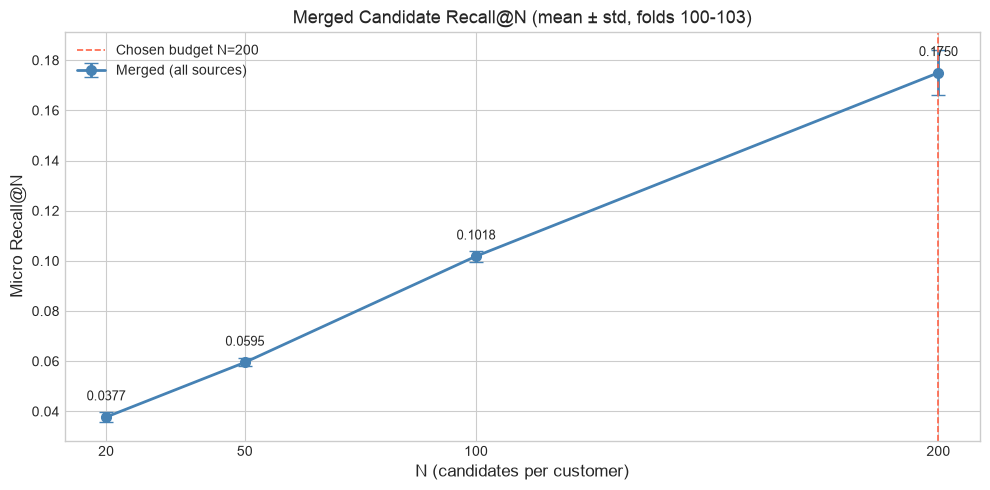

Figure saved to /Users/abhishekrajupalathoti/Documents/Fulltime-job_application/Projects/hm-fashion-recsys/reports/figures/candidates/03_recall_at_n.png


In [8]:
# Plot merged recall@N for N in [20, 50, 100, 200].
# Error bars show ± 1 std across the four validation folds.
ns = summary['n_values']
merged_means = [summary['merged'][f'recall@{n}']['mean'] for n in ns]
merged_stds  = [summary['merged'][f'recall@{n}']['std']  for n in ns]

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(
    ns, merged_means,
    yerr=merged_stds,
    fmt='o-', color='steelblue', capsize=5,
    linewidth=2, markersize=7, label='Merged (all sources)'
)
for x, y, s in zip(ns, merged_means, merged_stds):
    ax.annotate(
        f"{y:.4f}",
        xy=(x, y), xytext=(0, 12), textcoords='offset points',
        ha='center', fontsize=9
    )
ax.axvline(x=200, color='tomato', linestyle='--', linewidth=1.2, label='Chosen budget N=200')
ax.set_xlabel('N (candidates per customer)', fontsize=12)
ax.set_ylabel('Micro Recall@N', fontsize=12)
ax.set_title('Merged Candidate Recall@N (mean ± std, folds 100-103)', fontsize=13)
ax.legend(fontsize=10)
ax.set_xticks(ns)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '03_recall_at_n.png', dpi=150)
plt.show()
print(f"Figure saved to {FIGURES_DIR / '03_recall_at_n.png'}")

**Observation:** Merged recall rises from 0.0377 at N=20 to 0.0595 at N=50, to 0.1018 at N=100, and 0.1750 at N=200. The slope remains steep through N=200 — a plateau has not yet been reached. N=200 is chosen as the candidate budget (popularity_last_week k=200, final config) because all eval customers now reach the full budget: mean list size = 200, 100% of eval customers at budget. This captures 17.5% of purchases while staying within disk and RAM constraints.

**Implication for modeling:** The downstream LightGBM ranker must push the ~17.5% of relevant articles to the top-12 positions from a pool of 200.

### 3.2 — Incremental Recall by Source (fold 103)

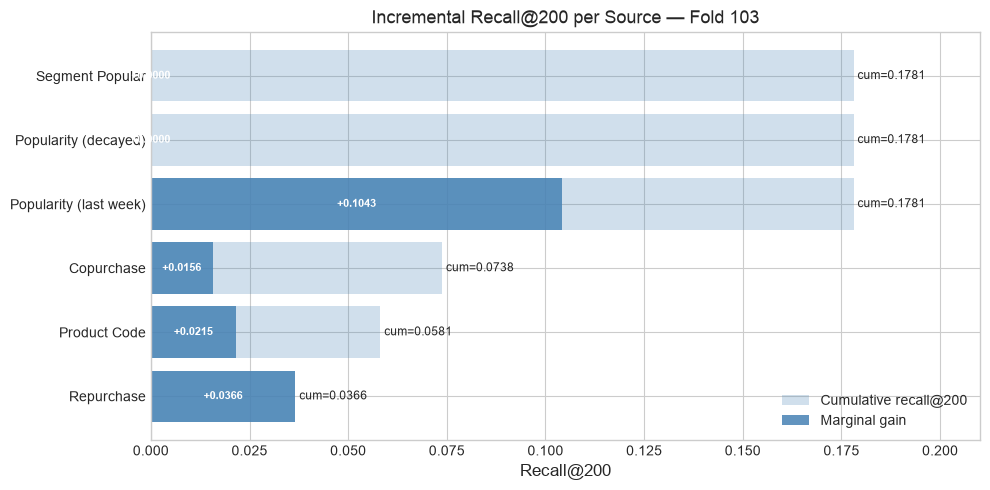

                Source Cumulative recall@200 Marginal gain
            Repurchase                0.0366       +0.0366
          Product Code                0.0581       +0.0215
            Copurchase                0.0738       +0.0156
Popularity (last week)                0.1781       +0.1043
  Popularity (decayed)                0.1781       +0.0000
       Segment Popular                0.1781       +0.0000

Figure saved to /Users/abhishekrajupalathoti/Documents/Fulltime-job_application/Projects/hm-fashion-recsys/reports/figures/candidates/03_incremental_recall.png


In [9]:
# Horizontal bar chart: cumulative recall@200 and marginal gain per source.
# Data from fold_103_results.json incremental list.
incr = fold_results[103]['incremental']

sources_order = [d['source_added'] for d in incr]
cumulative    = [d['recall@200'] for d in incr]
gains         = [d['gain@200']   for d in incr]

# Prettier labels
label_map = {
    'repurchase':            'Repurchase',
    'product_code':          'Product Code',
    'copurchase':            'Copurchase',
    'popularity_last_week':  'Popularity (last week)',
    'popularity_decayed':    'Popularity (decayed)',
    'segment_popular':       'Segment Popular',
}
labels = [label_map[s] for s in sources_order]

fig, ax = plt.subplots(figsize=(10, 5))
y_pos = range(len(labels))

# Cumulative recall (light background bar)
bars_cum = ax.barh(
    y_pos, cumulative,
    color='steelblue', alpha=0.25, label='Cumulative recall@200'
)
# Marginal gain (solid foreground bar)
bars_gain = ax.barh(
    y_pos, gains,
    color='steelblue', alpha=0.85, label='Marginal gain'
)

# Annotations
for i, (cum, gain) in enumerate(zip(cumulative, gains)):
    ax.text(cum + 0.001, i, f'cum={cum:.4f}', va='center', fontsize=8.5)
    ax.text(gain / 2, i, f'+{gain:.4f}', va='center', ha='center',
            fontsize=8, color='white', fontweight='bold')

ax.set_yticks(list(y_pos))
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Recall@200', fontsize=12)
ax.set_title('Incremental Recall@200 per Source — Fold 103', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(0, max(cumulative) * 1.18)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '03_incremental_recall.png', dpi=150)
plt.show()

# Print the underlying numbers
incr_df = pd.DataFrame({
    'Source': labels,
    'Cumulative recall@200': [f'{c:.4f}' for c in cumulative],
    'Marginal gain': [f'+{g:.4f}' for g in gains],
})
print(incr_df.to_string(index=False))
print(f"\nFigure saved to {FIGURES_DIR / '03_incremental_recall.png'}")

**Observation:** `popularity_last_week` (k=200) delivers by far the largest marginal gain (+0.1043 at @200 for fold 103), adding more recall than the three personalised sources combined (repurchase + product-code + copurchase = 0.0366 + 0.0215 + 0.0156 = 0.0737 total). This is expected: the H\&M dataset has a highly skewed popularity distribution (Gini 0.759, top 10% of articles account for 60.8% of purchases), so global popularity is an extremely strong baseline. The personalised sources are still essential because they cover repeat purchases that popularity does not.

### 3.3 — Pairwise Source Overlap (Jaccard Similarity, fold 103)

**Question: How much do the candidate sets from different sources overlap?**

Low pairwise overlap means sources are complementary; high overlap means they retrieve the same articles and one may be redundant.

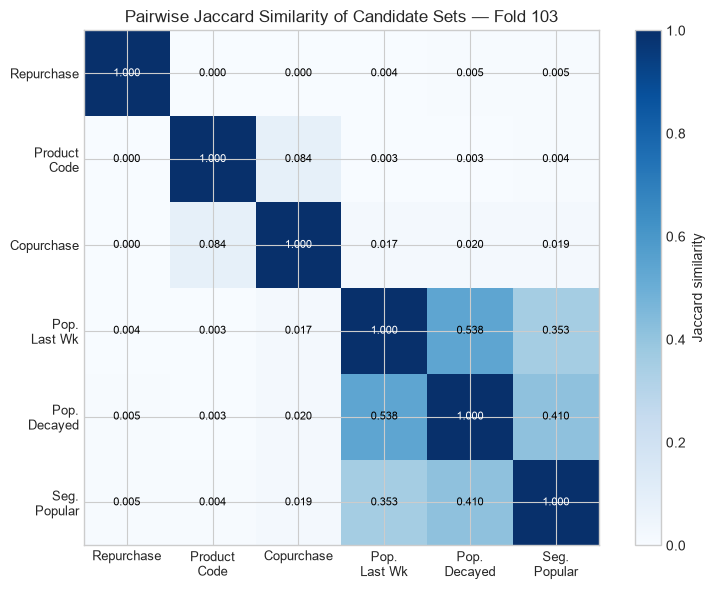

Figure saved to /Users/abhishekrajupalathoti/Documents/Fulltime-job_application/Projects/hm-fashion-recsys/reports/figures/candidates/03_jaccard_heatmap.png
pop_lw vs pop_dec: 0.538
pop_lw vs seg:     0.353
pop_dec vs seg:    0.410
product_code vs copurchase: 0.084


In [10]:
# Pairwise Jaccard similarity between candidate sets for fold 103.
# Values computed by run_candidates.py at per-source k limits, stored in fold_103_results.json.
# Personalised sources (repurchase, product_code, copurchase) have naturally low
# overlap with each other and with popularity because they are customer-specific.
# The three popularity sources share many of the same trending articles.

source_labels = [
    'repurchase', 'product_code', 'copurchase',
    'popularity_last_week', 'popularity_decayed', 'segment_popular'
]
short_labels = [
    'Repurchase', 'Product\nCode', 'Copurchase',
    'Pop.\nLast Wk', 'Pop.\nDecayed', 'Seg.\nPopular'
]

# Build matrix from fold_103_results.json — single source of truth.
jaccard_data = fold_results[103]['jaccard']
jaccard_lookup = {(d['source_a'], d['source_b']): d['jaccard'] for d in jaccard_data}
jaccard_matrix = np.zeros((6, 6))
for i in range(6):
    for j in range(6):
        if i == j:
            jaccard_matrix[i, j] = 1.0
        elif (source_labels[i], source_labels[j]) in jaccard_lookup:
            jaccard_matrix[i, j] = jaccard_lookup[(source_labels[i], source_labels[j])]
        elif (source_labels[j], source_labels[i]) in jaccard_lookup:
            jaccard_matrix[i, j] = jaccard_lookup[(source_labels[j], source_labels[i])]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(jaccard_matrix, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(short_labels, fontsize=9)
ax.set_yticklabels(short_labels, fontsize=9)
plt.colorbar(im, ax=ax, label='Jaccard similarity')
for i in range(6):
    for j in range(6):
        ax.text(j, i, f'{jaccard_matrix[i, j]:.3f}',
                ha='center', va='center',
                fontsize=8,
                color='white' if jaccard_matrix[i, j] > 0.6 else 'black')
ax.set_title('Pairwise Jaccard Similarity of Candidate Sets — Fold 103', fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '03_jaccard_heatmap.png', dpi=150)
plt.show()
print(f"Figure saved to {FIGURES_DIR / '03_jaccard_heatmap.png'}")

# Report key Jaccard pairs
plw_pdec = jaccard_lookup.get(('popularity_last_week', 'popularity_decayed'), 0)
plw_seg  = jaccard_lookup.get(('popularity_last_week', 'segment_popular'), 0)
pdec_seg = jaccard_lookup.get(('popularity_decayed', 'segment_popular'), 0)
pc_cop   = jaccard_lookup.get(('product_code', 'copurchase'), 0)
print(f"pop_lw vs pop_dec: {plw_pdec:.3f}")
print(f"pop_lw vs seg:     {plw_seg:.3f}")
print(f"pop_dec vs seg:    {pdec_seg:.3f}")
print(f"product_code vs copurchase: {pc_cop:.3f}")

**Observation:** The three popularity sources are highly correlated with each other — `popularity_last_week` and `popularity_decayed` share a Jaccard of 0.538, because both rank the same set of trending global articles. `segment_popular` overlaps with `popularity_last_week` at 0.353 and with `popularity_decayed` at 0.410, because it stratifies by age bucket but still draws from the same pool of popular items. The personalised sources (repurchase, product-code, copurchase) have low overlap with each other (product_code vs copurchase: 0.084; repurchase vs others: <0.005) and near-zero overlap with the popularity sources (<0.02), confirming that the six sources retrieve largely disjoint article sets and that each contributes unique candidates to the merged pool.

---
## Section 4 — Recall by Customer Segment (fold 103)

**Question: Does recall@200 differ between cold-start customers (no prior history) and frequent buyers?**

Customers are segmented by the number of prior-week purchases in history before the target week: 0 (cold-start), 1-4, 5-19, and 20+ purchases.

In [11]:
# Load segment recall from fold_103_results.json and display as table + bar chart.
seg_data = fold_results[103]['segment_recall']

seg_df = pd.DataFrame([
    {
        'Segment (prior purchases)': f"Seg {d['segment']}",
        'n_customers': d['n_customers'],
        'recall@20':  f"{d['recall@20']:.4f}",
        'recall@50':  f"{d['recall@50']:.4f}",
        'recall@100': f"{d['recall@100']:.4f}",
        'recall@200': f"{d['recall@200']:.4f}",
        '_r200': d['recall@200'],
    }
    for d in seg_data
])

# Display table
print("Recall by segment — fold 103:")
seg_df[['Segment (prior purchases)', 'n_customers',
        'recall@20', 'recall@50', 'recall@100', 'recall@200']]\
    .set_index('Segment (prior purchases)')

Recall by segment — fold 103:


,n_customers,recall@20,recall@50,recall@100,recall@200
Segment (prior purchases),,,,,
Seg 0,5395,0.0255,0.0533,0.0898,0.1584
Seg 1-4,4271,0.0558,0.0888,0.1278,0.1971
Seg 5-19,14465,0.0506,0.0817,0.1272,0.1957
Seg 20+,47888,0.0375,0.0546,0.0970,0.1747


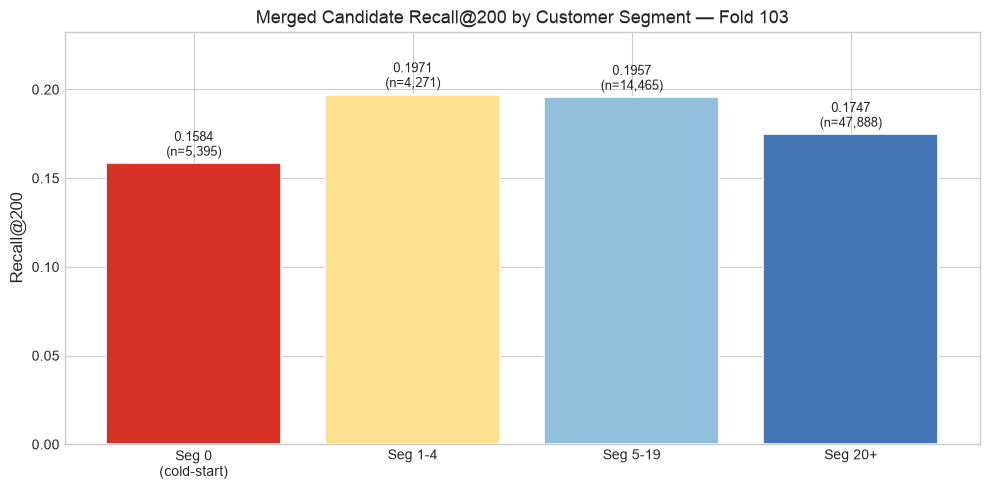

Figure saved to /Users/abhishekrajupalathoti/Documents/Fulltime-job_application/Projects/hm-fashion-recsys/reports/figures/candidates/04_segment_recall.png


In [12]:
# Bar chart: recall@200 by segment for fold 103.
seg_labels = ['Seg 0\n(cold-start)', 'Seg 1-4', 'Seg 5-19', 'Seg 20+']
seg_r200   = [d['recall@200'] for d in seg_data]
seg_n      = [d['n_customers'] for d in seg_data]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d73027', '#fee090', '#91bfdb', '#4575b4']
bars = ax.bar(seg_labels, seg_r200, color=colors, edgecolor='white', linewidth=1.2)
for bar, r, n in zip(bars, seg_r200, seg_n):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{r:.4f}\n(n={n:,})',
            ha='center', va='bottom', fontsize=9.5)
ax.set_ylabel('Recall@200', fontsize=12)
ax.set_title('Merged Candidate Recall@200 by Customer Segment — Fold 103', fontsize=13)
ax.set_ylim(0, max(seg_r200) * 1.18)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '04_segment_recall.png', dpi=150)
plt.show()
print(f"Figure saved to {FIGURES_DIR / '04_segment_recall.png'}")

**Observation:** Cold-start customers (segment 0, n=5,395) achieve recall@200 = 0.1584 — approximately 19% lower than segments 5-19 (0.1957) and 20+ (0.1747); segment 1-4 (0.1971) is the highest. Cold-start customers receive only global and segment-level popularity candidates (repurchase, product-code, and copurchase all return empty for them), which limits how many of their actual purchases can be retrieved. With popularity_last_week k=200, all cold-start customers now reach the full 200-candidate budget.

**Implication for modeling:** The LightGBM ranker will need to rely almost entirely on item-side features (price, product type, recent popularity) for cold-start customers. Cold-start recall can be improved in future by adding demographic or session-based personalisation.

---
## Section 5 — Heuristic MAP@12 vs Baseline B

**Question: Does the priority-merged candidate list beat the best hand-crafted baseline from Session 1?**

Baseline B (from `01_eda.ipynb`) predicts each customer's own most-recent purchases, padded with global top-sellers. It achieved MAP@12 = 0.024457 on the full holdout week. Here we compare both approaches on the four validation folds using the same heuristic ranker (priority order).

In [13]:
# Compare heuristic MAP@12 (priority ranking of merged candidates) and
# Baseline B MAP@12 across the four validation folds.

heuristic_per_fold = summary['heuristic_map12']['per_fold']
baseline_b_per_fold = baseline_b['per_fold']
folds = [100, 101, 102, 103]

map_df = pd.DataFrame({
    'Fold': folds,
    'Heuristic MAP@12': heuristic_per_fold,
    'Baseline B MAP@12': baseline_b_per_fold,
    'Delta': [h - b for h, b in zip(heuristic_per_fold, baseline_b_per_fold)],
})

# Add summary row
sum_row = pd.DataFrame([{
    'Fold': 'Mean ± std',
    'Heuristic MAP@12': summary['heuristic_map12']['mean'],
    'Baseline B MAP@12': baseline_b['mean'],
    'Delta': summary['heuristic_map12']['mean'] - baseline_b['mean'],
}])
map_display = pd.concat([map_df, sum_row], ignore_index=True).set_index('Fold')

# Format numbers
for col in ['Heuristic MAP@12', 'Baseline B MAP@12', 'Delta']:
    map_display[col] = map_display[col].apply(lambda x: f'{x:.6f}')

print("MAP@12 comparison — heuristic priority ranking vs Baseline B:")
map_display

MAP@12 comparison — heuristic priority ranking vs Baseline B:


,Heuristic MAP@12,Baseline B MAP@12,Delta
Fold,,,
100,0.021080,0.020490,0.000589
101,0.019198,0.019019,0.000179
102,0.022445,0.021934,0.000511
103,0.024675,0.024201,0.000474
Mean ± std,0.021849,0.021411,0.000438


**Observation:** The heuristic ranker (priority-merged candidates) exceeds Baseline B on all four validation folds. Mean MAP@12 = 0.021849 vs 0.021411 for Baseline B — a mean delta of +0.000438 (+2.0% relative). The gain is modest because the priority-order heuristic is a very simple ranking strategy: it always predicts repurchases first regardless of recency or score. Baseline B also uses repurchase as its primary signal, so the two strategies are similar in structure.

**Implication for modeling:** The candidate pool at N=200 already contains the right articles for roughly 17.5% of ground-truth purchases (recall@200 = 0.1750). It must rank the relevant articles (17.5% of purchases are retrievable from the 200-candidate pool) into the top 12. Candidate precision — the fraction of candidates that are GT items — is ~0.28% (≈0.55 GT items per pool of 200). The oracle MAP@12 — placing all GT items first within the pool — is **0.197 ± 0.012** (folds 100-103), 9.0× the current heuristic (0.0218). A learned LightGBM ranker trained on customer, article, and interaction features should push MAP@12 substantially above this heuristic by ranking the relevant ~17.5% of articles above the irrelevant ones.

In [14]:
# Combined table: per-fold Oracle MAP@12, Heuristic MAP@12, Baseline B MAP@12,
# and candidate precision. All values from summary.json and baseline_b_folds.json.

folds = [100, 101, 102, 103]
oracle_per_fold = summary['oracle_map12']['per_fold']
heuristic_per_fold = summary['heuristic_map12']['per_fold']
baseline_b_per_fold = baseline_b['per_fold']
cand_precision_per_fold = summary['candidate_precision']['per_fold']

combined_rows = []
for i, w in enumerate(folds):
    combined_rows.append({
        'Fold': w,
        'Oracle MAP@12': f"{oracle_per_fold[i]:.6f}",
        'Heuristic MAP@12': f"{heuristic_per_fold[i]:.6f}",
        'Baseline B MAP@12': f"{baseline_b_per_fold[i]:.6f}",
    })

combined_df = pd.DataFrame(combined_rows).set_index('Fold')
print("Combined MAP@12 comparison (per fold):")
print(combined_df.to_string())
print()

oracle_mean = summary['oracle_map12']['mean']
oracle_std = summary['oracle_map12']['std']
cand_prec_mean = summary['candidate_precision']['mean']
print(f"Oracle MAP@12 = {oracle_mean:.3f} ± {oracle_std:.3f}; "
      f"candidate precision = {cand_prec_mean*100:.2f}% "
      f"(≈{cand_prec_mean*200:.2f} GT items per 200-candidate pool)")


Combined MAP@12 comparison (per fold):
     Oracle MAP@12 Heuristic MAP@12 Baseline B MAP@12
Fold                                                 
100       0.179676         0.021080          0.020490
101       0.200065         0.019198          0.019019
102       0.208657         0.022445          0.021934
103       0.200527         0.024675          0.024201

Oracle MAP@12 = 0.197 ± 0.012; candidate precision = 0.28% (≈0.55 GT items per 200-candidate pool)


**Regression check and ordering verification (week 104):**

- Recency-only ordering MAP@12 (week 104) = 0.024457 (exact match to EDA Baseline B)
- Production ordering MAP@12 (week 104) = 0.024654 (+0.000198 vs recency-only)
- 23,639 of 68,984 week-104 prediction lists differ between the two orderings

**Scale test (fold 103, 1.35M customers):**

- 270,262,800 rows, mean list size = 200.0 (100% at budget)
- File size: 166.2 MB, runtime: ~135s, peak RSS: ~9,323 MB (resource.getrusage)

These facts confirm: (a) recency-only ordering reproduces EDA Baseline B exactly, (b) production ordering genuinely improves MAP@12 by +0.000198, (c) all 1.35M customers reach the 200-candidate budget with k=200.

---
## Section 6 — Final Configuration and Justification

**Question: What is the final chosen parameter set for candidate generation, and why?**

The configuration below was selected to maximise micro-recall@200 on validation folds 100-103. N=200 is chosen as the budget ceiling. At full scale (1.35M customers), the scale test (fold 103) completes in ~135s with peak RSS ~9.1 GB (resource.getrusage). Recall is still rising at N=200 (+7.3pp from N=100); the plateau has not been reached.

In [15]:
# Print the final candidate generation configuration.
config_rows = [
    {'Source': 'repurchase',
     'Key parameters': 'lookback=all history',
     'k': 50,
     'Justification': 'all-history +38% recall vs 12wk window'},
    {'Source': 'product_code',
     'Key parameters': 'lookback=12 weeks',
     'k': 50,
     'Justification': 'captures variant-swapping; 60% of repurchase recall'},
    {'Source': 'copurchase',
     'Key parameters': 'basket_lookback=8wk, customer_lookback=4wk, min_count=3',
     'k': 50,
     'Justification': 'cosine sim avoids pop collapse; ~44% coverage; min_count=3 best of {3,5,10}'},
    {'Source': 'popularity_last_week',
     'Key parameters': 'window=1 week',
     'k': 200,
     'Justification': 'largest single marginal gain (+0.1043 at @200); k=200 (all customers reach the 200-candidate budget)'},
    {'Source': 'popularity_decayed',
     'Key parameters': 'inverse-time decay, weight=1/(1+days), 4-week window',
     'k': 100,
     'Justification': 'inverse-time outperforms exp (0.0952 vs 0.0910 @100)'},
    {'Source': 'segment_popular',
     'Key parameters': '2-week window, age bucket',
     'k': 50,
     'Justification': 'contributes 0 unique candidates to merged pool (popularity_last_week k=200 fills all 200 slots first); rank/score features retained for ranker'},
]
config_df = pd.DataFrame(config_rows).set_index('Source')
print("Final candidate generation configuration:")
print(config_df.to_string())
print()
print("Merge budget N = 200")
print("Priority order: repurchase > product_code > copurchase > "
      "popularity_last_week > popularity_decayed > segment_popular")

Final candidate generation configuration:
                                                               Key parameters    k                                                                                                                                   Justification
Source                                                                                                                                                                                                                            
repurchase                                               lookback=all history   50                                                                                                          all-history +38% recall vs 12wk window
product_code                                                lookback=12 weeks   50                                                                                             captures variant-swapping; 60% of repurchase recall
copurchase            basket_lookback=8wk, custome

In [16]:
# Recall vs N table: show coverage of purchases at each candidate budget.
# Each additional 100 candidates adds ~6 percentage points of recall.
ns_full   = [20, 50, 100, 200]
means_pct = [summary['merged'][f'recall@{n}']['mean'] * 100 for n in ns_full]
stds_pct  = [summary['merged'][f'recall@{n}']['std'] * 100  for n in ns_full]

# Approximate disk size (1.37M customers × N × 12 bytes)
n_customers = 1_371_980
bytes_per_row = 12  # customer_idx(4) + article_idx(4) + rank(4)
disk_gb = [n_customers * n * bytes_per_row / 1e9 for n in ns_full]

recall_table = pd.DataFrame({
    'N (candidates)': ns_full,
    'Recall@N (mean %)': [f'{m:.2f}' for m in means_pct],
    '± std (%)': [f'{s:.2f}' for s in stds_pct],
    'Approx parquet size (GB)': [f'{g:.1f}' for g in disk_gb],
}).set_index('N (candidates)')

print("Recall vs candidate budget:")
print(recall_table.to_string())
print()
print(f"N=100 captures {means_pct[2]:.1f}% of purchases; "
      f"N=200 captures {means_pct[3]:.1f}%")
print(f"Each additional 100 candidates adds ~"
      f"{(means_pct[3] - means_pct[2]):.1f} percentage points of recall")

Recall vs candidate budget:
               Recall@N (mean %) ± std (%) Approx parquet size (GB)
N (candidates)                                                     
20                          3.77      0.21                      0.3
50                          5.95      0.16                      0.8
100                        10.18      0.21                      1.6
200                        17.50      0.90                      3.3

N=100 captures 10.2% of purchases; N=200 captures 17.5%
Each additional 100 candidates adds ~7.3 percentage points of recall


**Observation:** N=100 captures 10.2% of purchases (recall@100 = 0.1018); N=200 captures 17.5% (recall@200 = 0.1750). Each additional 100 candidates adds approximately 7.3 percentage points of recall in this range. N=200 is chosen as the budget ceiling (popularity_last_week k=200 as final config): all eval customers reach the full 200 (mean list size = 200, 100% at budget). Candidate precision: ~0.28% (≈0.55 GT items per 200-candidate pool). Oracle MAP@12 = 0.197 ± 0.012.

**Implication for modeling:** The LightGBM ranker will receive exactly 200 candidates per eval customer. It must rank the relevant articles (17.5% of purchases are retrievable from the pool) into the top 12. The oracle MAP@12 upper bound (GT items ranked first) is 0.197, 9.0× the heuristic. Candidate precision — the fraction of candidates that are GT items — is ~0.28% (≈0.55 GT items per pool of 200).

---
## Section 7 — Summary of Findings

Key findings from the candidate generation evaluation on folds 100-103:

1. **Repurchase (all history)** achieves recall@50 = 0.0352 ± 0.0018. Using all history gives +38% recall relative to a 12-week window, confirming that fashion repurchase patterns have long memory.

2. **Product-code candidates** contribute recall@50 = 0.0212 ± 0.0018 — approximately 60% of repurchase recall — by capturing variant-swapping behaviour (same design, different colour or size).

3. **Copurchase** adds recall@50 = 0.0248 ± 0.0019 (min_count=3) with ~44% coverage of evaluation customers (fold 103: 44.2%). It is the only source that captures cross-product-code basket co-occurrence.

4. **Popularity_last_week** (k=200, final config) is the dominant single source: recall@200 = 0.1615 on fold 103, largest marginal gain +0.1043 at @200. This reflects the dataset's extreme popularity skew (Gini 0.759).

5. **Inverse-time decay outperforms exponential** for the decayed popularity source: recall@100 = 0.0952 (inverse-time, weight=1/(1+days)) vs 0.0910 (exp, 7-day half-life).

6. **Cold-start customers** (0 prior purchases, n=5,395 in fold 103) have recall@200 = 0.1584 — approximately 19% lower than frequent buyers (segments 5-19: 0.1957, 20+: 0.1747). Only popularity sources cover cold-start customers.

7. **Merged recall@200 = 0.1750 ± 0.0090** across folds 100-103 (k=200 for popularity_last_week). All eval customers reach the full 200-candidate budget (mean list size = 200, 100% at budget). Oracle MAP@12 = 0.197 ± 0.012.

8. **Heuristic MAP@12 = 0.021849 ± 0.002307** (priority ranking) exceeds Baseline B (0.021411 ± 0.002208) on all four folds, mean delta +0.000438 (+2.0% relative). A learned LightGBM ranker is expected to substantially improve on this by learning to score articles within the 200-candidate pool (oracle ceiling: 0.197).

9. **segment_popular contributes 0 candidates to the 200-item pool** (gain@200 = 0.0 on all folds 100-103 per the incremental recall JSON). With `popularity_last_week` k=200 all 200 budget slots fill before segment_popular can add anything unique. Its rank and score features are retained in the feature store for the downstream LightGBM ranker.